In [14]:
# Loading the dataset
# Importing pandas library
import pandas as pd
# Reading the dataset
mydata = pd.read_csv('C:/Users/Administrator/Desktop/Cut Off.csv')


In [15]:
# Displaying the dataset
mydata

,Monthly Inflation (%),Monthly GDP Growth (%),Trade Balance (USD Million),Monthly Interest Rate (%),GHc/USD,GHc/GBP,GHc/EUR,CCI,BCI,Gov Debt (% Debt to GDP),M2 (USD Million),Gold Price (USD per Troy Ounce),Oil Price (USD per Barrel),Cocoa Price (USD per Metric Ton)
0,10.14,6.95,-4937.0,12.44,0.93970,1.88519,1.27376,79.70,79.70,22.0,338.651,665.38,69.23,2151.67
1,10.41,6.32,-4366.0,12.33,0.95080,1.86797,1.24684,78.80,77.40,22.0,340.057,665.41,67.77,1902.09
2,10.19,5.79,-4520.0,11.71,0.95857,1.88694,1.30168,76.35,75.00,22.0,353.289,712.65,73.27,1965.14
3,10.14,5.35,-5411.0,12.24,0.96650,1.91846,1.34220,73.90,72.60,23.0,377.078,754.60,79.32,1916.67
4,11.40,4.96,-4441.0,12.44,0.96930,1.97439,1.39395,76.55,74.15,23.0,405.320,806.25,87.16,1967.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,11.50,4.29,49.1,25.00,10.78760,14.51720,12.56710,100.00,118.00,53.0,25229.358,3300.00,63.37,7604.12
218,9.40,3.96,1260.0,21.50,12.14430,16.40220,14.25160,103.00,120.00,54.0,25504.587,3500.00,62.23,7006.53
219,8.00,3.68,1080.0,21.50,11.46070,15.30770,13.33960,100.00,115.00,53.0,25871.560,4084.78,58.89,5953.57
220,6.30,5.15,1108.0,18.00,11.02370,14.48610,12.74580,92.00,119.00,56.0,26146.789,4447.77,58.13,5590.71


In [16]:
seed = 14

In [ ]:
# Preparing the target and feature variables

In [17]:
# The target variable or output
y_1 = mydata['GHc/USD']
y_2 = mydata['GHc/GBP']
y_3 = mydata['GHc/EUR']

In [18]:
y_1.shape
y_2.shape
y_3.shape

(222,)

In [19]:
print(y_1[:5])

0    0.93970
1    0.95080
2    0.95857
3    0.96650
4    0.96930
Name: GHc/USD, dtype: float64


In [20]:
print(y_2[:5])

0    1.88519
1    1.86797
2    1.88694
3    1.91846
4    1.97439
Name: GHc/GBP, dtype: float64


In [21]:
print(y_3[:5])

0    1.27376
1    1.24684
2    1.30168
3    1.34220
4    1.39395
Name: GHc/EUR, dtype: float64


In [22]:
# The feature varaibles
x = mydata.drop(['GHc/USD', 'GHc/GBP', 'GHc/EUR'], axis = 1)

In [23]:
x.shape

(222, 11)

In [24]:
print(x[:5])

   Monthly Inflation (%)  Monthly GDP Growth (%)  Trade Balance (USD Million)  \
0                  10.14                    6.95                      -4937.0   
1                  10.41                    6.32                      -4366.0   
2                  10.19                    5.79                      -4520.0   
3                  10.14                    5.35                      -5411.0   
4                  11.40                    4.96                      -4441.0   

   Monthly Interest Rate (%)    CCI    BCI  Gov Debt (% Debt to GDP)  \
0                      12.44  79.70  79.70                      22.0   
1                      12.33  78.80  77.40                      22.0   
2                      11.71  76.35  75.00                      22.0   
3                      12.24  73.90  72.60                      23.0   
4                      12.44  76.55  74.15                      23.0   

   M2 (USD Million)  Gold Price (USD per Troy Ounce)  \
0           338.651     

In [ ]:
# VIF and Scaling/Standardizing the features

In [25]:
# Splitting the dataset into training and testing datasets
# Importing the train_test_split function
from sklearn.model_selection import train_test_split

In [26]:
# Splitting the dataset
x_train, x_test, y_1_train, y_1_test = train_test_split(x, y_1, test_size = 0.20, random_state = 30, shuffle = True)

In [27]:
print(x_train.shape, x_test.shape, y_1_train.shape, y_1_test.shape)

(177, 11) (45, 11) (177,) (45,)


In [28]:
# Best parameter search
# Importing the necessary functions and libraries
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
from numpy import absolute
# Importing warnings () to ignore warning messages
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# SVR modeling and best parameter search

In [ ]:
model = SVR()
svr_param_grid = {'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
                   'epsilon': [0.001, 0.01, 0.1],
                    'C': [10, 50, 100]               
                 }
cv_svr = KFold(n_splits = 5, random_state = 1, shuffle = True)
svr = GridSearchCV(model, svr_param_grid, cv = cv_svr, scoring = 'neg_mean_squared_error', n_jobs = -1)
svr.fit(x,y_1)

In [18]:
# Printing the parameters and the best score
print('The best parameters are:', svr.best_params_)
print('The best score is:', svr.best_score_)

The best parameters are: {'C': 100, 'epsilon': 0.1, 'kernel': 'rbf'}
The best score is: -0.2979752883972246


In [19]:
# Fitting the model on the training dataset
model = SVR()
svr_param_grid = {'kernel': ['rbf'],
                   'epsilon': [0.1],
                   'C': [100]
}
cv_svr = KFold(n_splits = 5, random_state = 1, shuffle = True)
svr = GridSearchCV(model, svr_param_grid, cv = cv_svr, scoring = 'r2', n_jobs = -1)
svr.fit(x_train, y_1_train)


,estimator,SVR()
,param_grid,"{'C': [100], 'epsilon': [0.1], 'kernel': ['rbf']}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,kernel,'rbf'


In [20]:
# Evaluate the performance of the model on the training dataset
svr_y_1_predtr = svr.predict(x_train)

In [26]:
print('The training r-sq is:', r2_score(y_1_train, svr_y_1_predtr))
print('The training MAE is:', mean_absolute_error(y_1_train, svr_y_1_predtr))
print('The training MSE is:', mean_squared_error(y_1_train, svr_y_1_predtr))

The training r-sq is: 0.9866623474132302
The training MAE is: 0.19110672129953588
The training MSE is: 0.18348648539036427


In [29]:
# Evaluating the model on the testing dataset
svr_y_1_predts = svr.predict(x_test)
print('The testing r-sq is:', r2_score(y_1_test, svr_y_1_predts))
print('The testing MAE is:', mean_absolute_error(y_1_test, svr_y_1_predts))
print('The testing MSE is:', mean_squared_error(y_1_test, svr_y_1_predts))

The testing r-sq is: 0.9823555284318567
The testing MAE is: 0.3377411821759089
The testing MSE is: 0.4004512311489049


In [ ]:
# The cross-validation

In [38]:
# On the training dataset
cv_svrtr = cross_val_score(svr, x_train, y_1_train, scoring = 'neg_mean_squared_error', cv = 10)

In [39]:
cv_svrtr

array([-0.0957259 , -0.08471516, -0.0271028 , -0.04203461, -0.50948359,
       -1.0482634 , -0.10004306, -0.0834755 , -0.09810934, -0.13808544])

In [40]:
# The absolute mean score
print('The mean training cv score is:', absolute(np.mean(cv_svrtr)))

The mean training cv score is: 0.22270387978419698


In [41]:
# On the testing dataset
cv_svrts = cross_val_score(svr, x_test, y_1_test, scoring = 'neg_mean_squared_error', cv = 10)

In [42]:
cv_svrts

array([-1.99024569, -0.01626896, -1.20245539, -0.02032005, -0.17816887,
       -0.40108966, -0.08524137, -0.06075126, -0.04398379, -0.85018711])

In [43]:
# The absolute mean score
print('The mean testing cv score is:', absolute(np.mean(cv_svrts)))

The mean testing cv score is: 0.4848712148592022


In [47]:
# Plotting the prediction errors and residuals
from sklearn.preprocessing import StandardScaler

In [ ]:
# conda install conda-forge::yellowbrick in Anaconda prompt

In [ ]:
# Plotting the prediction error

In [50]:
from yellowbrick.regressor import PredictionError

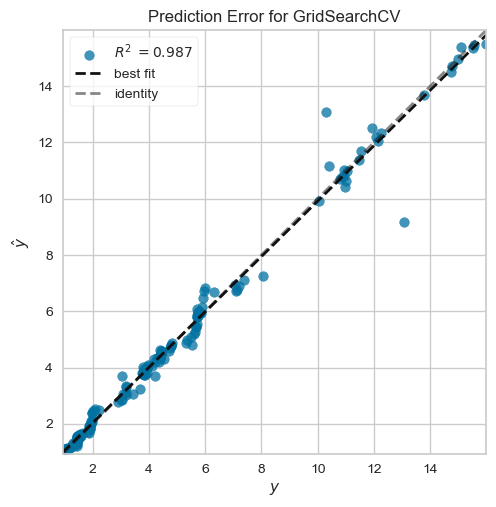

<Axes: title={'center': 'Prediction Error for GridSearchCV'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [53]:
visualizer = PredictionError(svr)
visualizer.fit(x_train, y_1_train)
visualizer.score(x_train, y_1_train)
visualizer.poof()


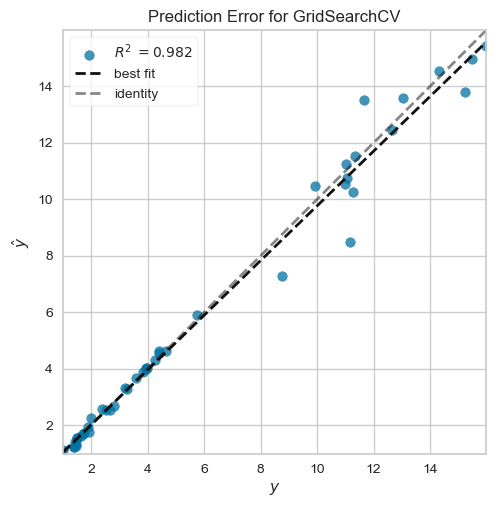

<Axes: title={'center': 'Prediction Error for GridSearchCV'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [54]:
visualizer = PredictionError(svr)
visualizer.fit(x_test, y_1_test)
visualizer.score(x_test, y_1_test)
visualizer.poof()

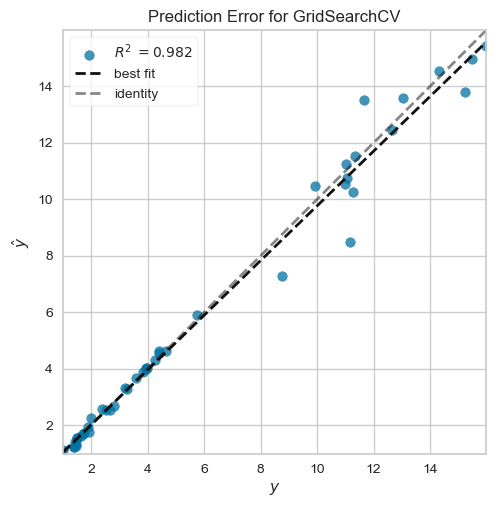

<Axes: title={'center': 'Prediction Error for GridSearchCV'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [54]:
visualizer = PredictionError(svr)
visualizer.fit(x_test, y_1_test)
visualizer.score(x_test, y_1_test)
visualizer.poof()

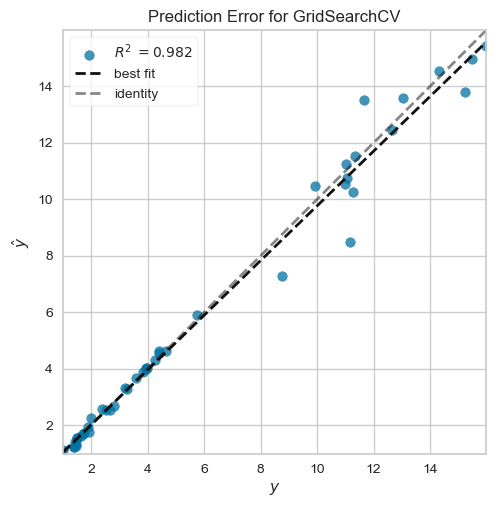

<Axes: title={'center': 'Prediction Error for GridSearchCV'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [54]:
visualizer = PredictionError(svr)
visualizer.fit(x_test, y_1_test)
visualizer.score(x_test, y_1_test)
visualizer.poof()

In [12]:
# Plotting the residuals
from yellowbrick.regressor import ResidualsPlot

In [13]:
visualizer = ResidualsPlot(svr)
visualizer.fit(x_train, y_1_train)
visualizer.score(x_train, y_1_train)
visualizer.poof()

NameError: name 'svr' is not defined

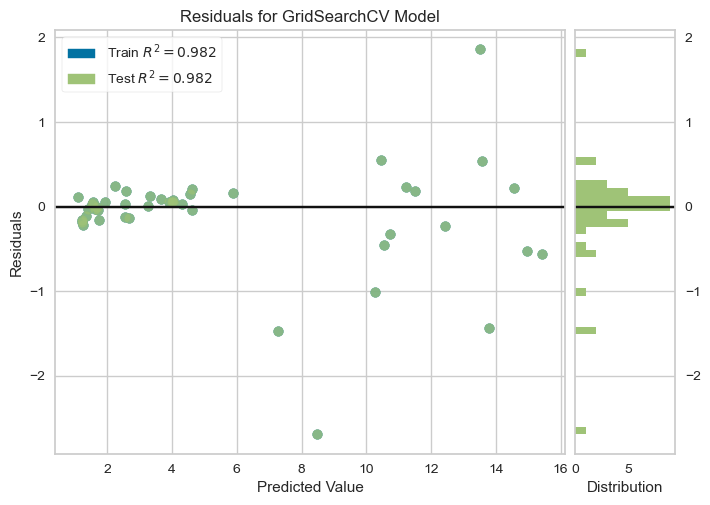

<Axes: title={'center': 'Residuals for GridSearchCV Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [62]:
visualizer = ResidualsPlot(svr)
visualizer.fit(x_test, y_1_test)
visualizer.score(x_test, y_1_test)
visualizer.poof()

In [9]:
# Plotting the observe against the predicted
import matplotlib.pyplot as plt

NameError: name 'y_1_train' is not defined

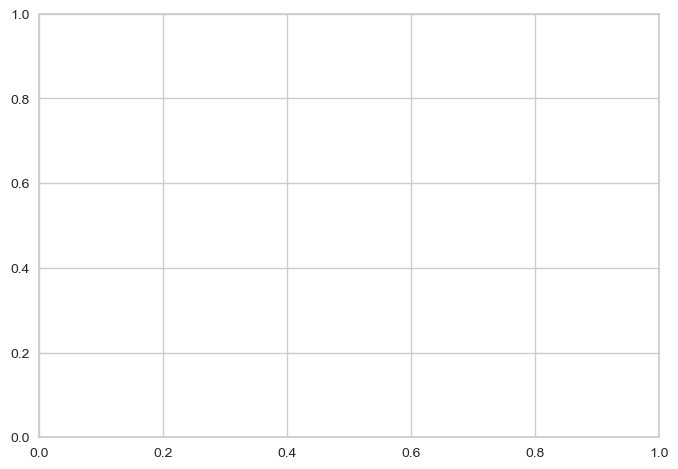

In [11]:
# For the training dataset
# Setting the boundaries and characteristics
fig, ax = plt.subplots()
ax.scatter(y_1_train, svr_y_1_predtr)
ax.plot([y_1_train.min(), y_1_train.max()], [y_1_train.min(), y_1_train.max()], 'k--', lw = 4)
# Labelling
ax.set_xlabel("Observed GHc/USD")
ax.set_ylabel('Predicted GHc/USD')
plt.title('Training Observed vs Predicted GHc/USD')
plt.show()

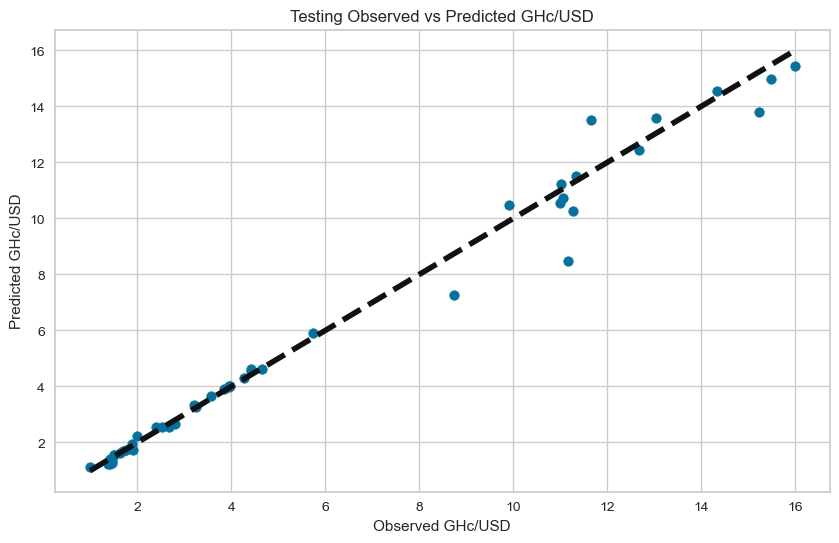

In [78]:
# For the testing dataset
# Setting the boundaries and characteristics
fig, ax = plt.subplots()
ax.scatter(y_1_test, svr_y_1_predts)
ax.plot([y_1_test.min(), y_1_test.max()], [y_1_test.min(), y_1_test.max()], 'k--', lw = 4)
# Labelling
ax.set_xlabel("Observed GHc/USD")
ax.set_ylabel('Predicted GHc/USD')
plt.title('Testing Observed vs Predicted GHc/USD')
plt.show()

In [ ]:
# Plotting the observed and predicted GHc/USD

In [2]:
# Setting the boundaries and characteristics
plt.rcParams['figure.figsize'] = (10,6)
x_ax = range(len(x_test))
plt.plot(x_ax, y_1_test, label = 'Observed', color = 'k', linestyle = '-', lw = 2.5)
plt.plot(x_ax, svr_y_1_predts, label = 'Predicted', color = 'b', linestyle = '--', lw = 2)
plt.ylabel('GHc/USD')
plt.xlabel('Sample')
plt.legend(bbox_to_anchor = (0.5, -0.2), loc = 'lower center', ncol = 2, frameon = False)
plt.show()

NameError: name 'plt' is not defined